# `Classification semi-supervisée Fixmatch`
- __Implémentation de l'algorithme de en PyTorch__

Dans ce notebook, vous allez compléter le code de l'algorithme Fixmatch, et le tester sur CIFAR10 en utilisant seulement 250 exemples supervisés et le reste en non-supervisé.

À faire :
- compléter le code de la fonction `fixMatchstepAlgo()`, voir plus bas
- réaliser un apprentissage supervisé sur les 250 exemples supervisés, pour comparaison avec le même modèle entraîné avec Fixmatch.


<img src="https://www.irit.fr/~Thomas.Pellegrini/ens/M2ML3/fixmatch_diagram.png" alt="diagram FixMatch" width="800"/>


## `Contexte et notations`

### `Apprentissage semi-supervisé`

- Problème de classification à $L$ classes exclusives
- Exemples labélisés : $\cal{X} = \{(x_b,p_b) : b \in (1,...,B)\}$
- Exemples non-labélisés : $\cal{U} = \{u_b : b \in (1,...,\mu B)\}$
- Le modèle prédit un label pour l'entrée $x$ : $q = p_m (\text{target}|x; \theta)$
- Cross-Entropy : $H(p, q)$
- Augmentations faibles (weak): $\alpha(x)$. 
  - Par exemple, rotations, translations, flips, etc
- Augmentations fortes (strong) : $\cal{A}(x)$. 
  - Éventuellement, on pourrait utiliser des augmentations qui s'apprennent : AutoAugment, CTAugment, etc


### `Loss sur les données supervisées :`

- Cross-Entropy loss : $L(x, \text{class}) = - \log(q[\text{class}])$


### `Loss sur les données non-supervisées :`

- Consistency loss avec $\cal{l}^2$ : $L(x) = |p_m (\text{target}| \alpha_1(x); \theta) - p_m (\text{target}| \alpha_2(x); \theta)|^2$
- Ou Consistency loss avec Cross-Entropy : $p_m (\text{target}| \alpha_1(x); \theta) \rightarrow \text{target}$, $p_m (\text{target}| \alpha_2(x); \theta) \rightarrow \text{prédiction}$

### `Pseudo-labeling`

1) Le modèle génère des prédictions utilisées ensuite comme labels pour les données non-su+pervisées.

2) Fixmatch utilise des labels binaires ("hard labels"), et sélectionne uniquement celles dont la probabilité donnée par le modèle est supérieure à un seuil prédéfini :  

- Prédiction : $q = p_m (\text{target}|x; \theta)$
- Pseudo-label : $\hat{q} = \text{argmax}(q)$
- "Hard" label : $\max(q) \ge \tau$
- Loss :
  - $H(\hat{q}, q)$ if $\max(q) \ge \tau$
  - $0$ sinon


In [1]:
%pip -q install IPython

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lrs
from torch.utils.data import Subset, Dataset, DataLoader
from torchvision import transforms as T
from torchvision.datasets.cifar import CIFAR10
from torchvision.models.resnet import resnet18
from torchvision.utils import make_grid

import matplotlib.pylab as plt
%matplotlib inline

In [3]:
import os
import torch
from IPython import get_ipython # type: ignore

def get_runtime_info():
    # 1) Détecter si on est sur Google Colab
    try:
        in_colab = 'google.colab' in str(get_ipython()) # type: ignore
    except NameError:
        in_colab = False

    # 2) Vérifier CUDA (GPU NVIDIA, typiquement sur Colab)
    cuda_available = torch.cuda.is_available()

    # 3) Vérifier MPS (GPU Apple Silicon, typiquement en local sur Mac)
    mps_available = getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available()

    if in_colab and cuda_available:
        device = torch.device("cuda")
        location = "colab_cuda"
    elif mps_available:
        device = torch.device("mps")
        location = "local_mps"
    else:
        device = torch.device("cpu")
        location = "cpu"

    return {
        "in_colab": in_colab,
        "cuda_available": cuda_available,
        "mps_available": mps_available,
        "device": device,
        "location": location,  # "colab_cuda", "local_mps" ou "cpu"
    }

info = get_runtime_info()
print("device",info["device"])
device=info["device"]


device mps


In [4]:
num_train_samples_per_class = 25
num_classes = 10
mu_ratio = 7
weight_decay = 0.0005
batch_size = 64

### `CIFAR10 dataset`

In [5]:
class TransformedDataset(Dataset):

    def __init__(self, dataset, transforms):
        self.dataset = dataset
        self.transforms = transforms

    def __getitem__(self, i):
        dp = self.dataset[i]
        return self.transforms(dp)

    def __len__(self):
        return len(self.dataset)

In [6]:
rep_path= "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TPIA3_3/data/"
full_train_dataset = CIFAR10(rep_path, train=True, download=True)
full_test_dataset = CIFAR10(rep_path, train=False, download=False)

Files already downloaded and verified


In [7]:
print(full_test_dataset.meta)
print(full_test_dataset.classes)
label2id = {c: i for i, c in enumerate(full_test_dataset.classes)}
id2label = {v: k for k, v in label2id.items()}

{'filename': 'batches.meta', 'key': 'label_names', 'md5': '5ff9c542aee3614f3951f8cda6e48888'}
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


`Nous permet d'équilibrer le nombre d'occurences par classes` 

In [8]:
supervised_train_indices = []
counter = [0] * num_classes

for i, dp in enumerate(full_train_dataset): # (<PIL.Image.Image image mode=RGB size=32x32 at 0x132A5F910>, 6)
    if len(supervised_train_indices) >= num_classes * num_train_samples_per_class:
        break
    if counter[dp[1]] < num_train_samples_per_class: # limite le nombre de classes
        counter[dp[1]] += 1 # incrémente à l'indice de la classe le nombre d'occurence [0, 2, 0, 0, 1, 0, 1, 0, 0, 2]
        supervised_train_indices.append(i)

for cls_id, n in enumerate(counter):
    print(f"{n} échantillons de la classe {id2label[cls_id]}")
print(f"Total : {sum(counter)}")

print(f'sum(counter) : {sum(counter)}')
supervised_train_dataset = Subset(full_train_dataset, supervised_train_indices)
print(f'le nombre de classe pour le trainset est de {len(supervised_train_dataset)}')

25 échantillons de la classe airplane
25 échantillons de la classe automobile
25 échantillons de la classe bird
25 échantillons de la classe cat
25 échantillons de la classe deer
25 échantillons de la classe dog
25 échantillons de la classe frog
25 échantillons de la classe horse
25 échantillons de la classe ship
25 échantillons de la classe truck
Total : 250
sum(counter) : 250
le nombre de classe pour le trainset est de 250


## __` 1. WiseNet`__
#### `1.1 TestLoader pour WiseNet`

In [ ]:
test_transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.25, 0.25, 0.25))
])

test_loader = DataLoader(
    TransformedDataset(
        full_test_dataset,
        transforms=lambda dp: {"image": test_transforms(dp[0]), "target": dp[1]}
    ),
    batch_size=batch_size, num_workers=0, pin_memory=False, drop_last=False, shuffle=False
)

#### `1.2 Supervised TrainLoader pour WiseNet`

In [ ]:
weak_transforms = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.5, 0.5),
    T.ToTensor(),
    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.25, 0.25, 0.25))
])

supervised_train_loader = DataLoader(
    TransformedDataset(
        supervised_train_dataset,
        transforms=lambda dp: {"image": weak_transforms(dp[0]), "target": dp[1]}
    ),
    batch_size=batch_size, num_workers=0, pin_memory=False, drop_last=False, shuffle=True
)

#### `1.3 Extrait du dataset`

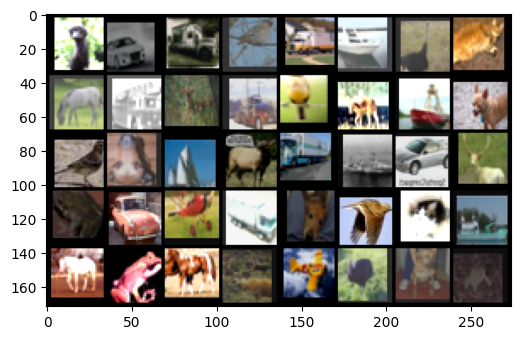

In [ ]:
supervised_train_loader_iter = iter(supervised_train_loader)
sup_batch = next(supervised_train_loader_iter)

sup_weak_aug_batch = make_grid(sup_batch["image"][:40, ...], normalize=True)
plt.figure(figsize=(6, 4))
plt.imshow(sup_weak_aug_batch.numpy().transpose((1, 2, 0)))
plt.show()

#### `1.4 Unsupervised TrainLoader pour WiseNet`

In [ ]:
strong_transforms = T.Compose([
    T.RandomAffine(45, translate=(0.2, 0.2), scale=(0.7, 1.2), shear=10),
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(0.15, 0.15, 0.15, 0.15),
    T.ToTensor(),
    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.25, 0.25, 0.25)),
    T.RandomErasing(scale=(0.02, 0.15))
])

unsupervised_train_dataset = TransformedDataset(
    full_train_dataset,
    transforms=lambda dp: {"image": weak_transforms(dp[0]), "strong_aug": strong_transforms(dp[0])}
)

unsupervised_train_loader = DataLoader(
    unsupervised_train_dataset,
    batch_size=batch_size * mu_ratio, num_workers=0, pin_memory=False, drop_last=False, shuffle=True
)

### `1.5 Extrait de la transformation`

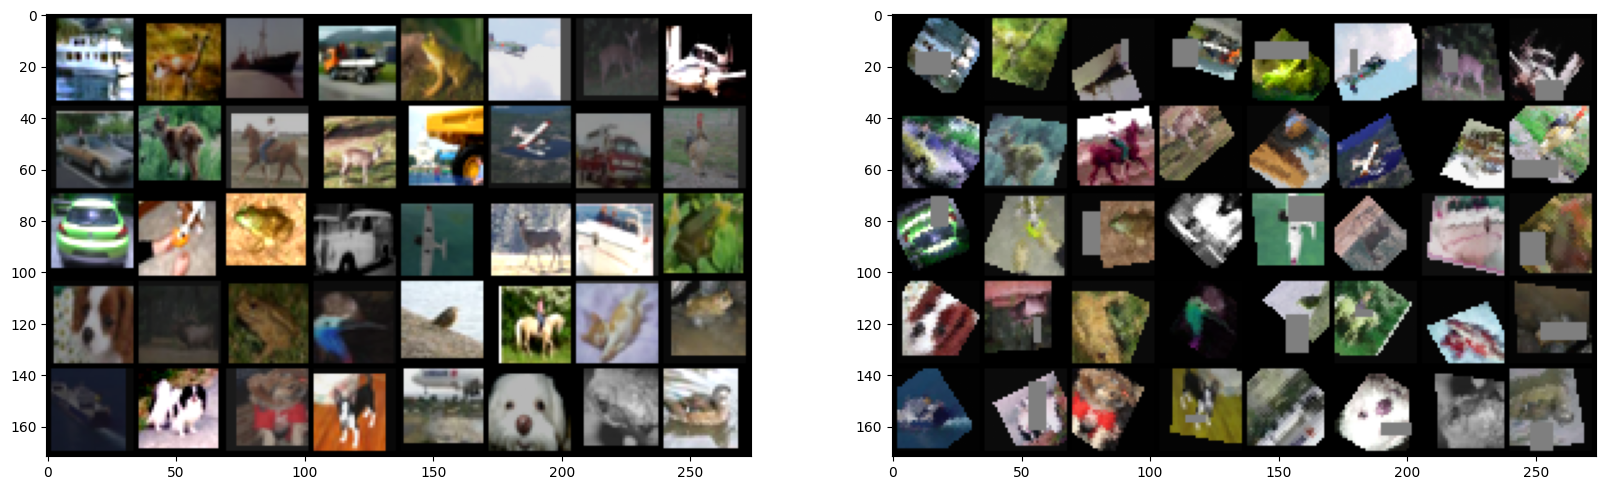

In [ ]:
unsupervised_train_loader_iter = iter(unsupervised_train_loader)
unsup_batch = next(unsupervised_train_loader_iter)

unsup_weak_aug_batch = make_grid(unsup_batch["image"][:40, ...], normalize=True)
unsup_strong_aug_batch = make_grid(unsup_batch["strong_aug"][:40, ...], normalize=True)
plt.figure(figsize=(20, 7))
plt.subplot(121)
plt.imshow(unsup_weak_aug_batch.numpy().transpose((1, 2, 0)))
plt.subplot(122)
plt.imshow(unsup_strong_aug_batch.numpy().transpose((1, 2, 0)))
plt.show()

### `1.6 Modèle Wide-ResNet-28-2`

https://github.com/google-research/fixmatch/blob/08d9b83d7cc87e853e6afc5a86b12aacff56cdea/libml/models.py#L62

In [14]:
import torch.nn as nn

class Residual(nn.Module):

    def __init__(self, in_channels, out_channels, stride, activate_before_residual=False):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.001)
        self.leaky_relu = nn.LeakyReLU(0.1, inplace=True)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels, momentum=0.001)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)

        self.activate_before_residual = activate_before_residual
        if in_channels == out_channels:
            self.skip = nn.Identity()
        else:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, padding=0)

    def forward(self, x0):
        x = self.leaky_relu(self.bn1(x0))
        if self.activate_before_residual:
            x0 = x
        x = self.leaky_relu( self.bn2( self.conv1(x) ) )
        x = self.conv2(x)
        x0 = self.skip(x0)
        return x0 + x


class WideResNet(nn.Module):

    def __init__(self, num_classes=10, scales=3, filters=32, repeat=4):
        super().__init__()
        self.conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)

        b0 = nn.Sequential(
            Residual(16, filters, stride=1, activate_before_residual=True),
            *[Residual(filters, filters, stride=1) for _ in range(repeat - 1)]
        )
        b1 = nn.Sequential(
            Residual(filters, filters * 2, stride=2),
            *[Residual(filters * 2, filters * 2, stride=1) for _ in range(repeat - 1)]
        )
        b2 = nn.Sequential(
            Residual(filters * 2, filters * 4, stride=2),
            *[Residual(filters * 4, filters * 4, stride=1) for _ in range(repeat - 1)]
        )
        self.res_blocks = nn.Sequential(b0, b1, b2)
        self.leaky_relu = nn.LeakyReLU(0.1, inplace=True)
        self.bn = nn.BatchNorm2d(filters * 4, momentum=0.001)
        self.reduce = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(filters * 4, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.res_blocks(x)
        x = self.bn(x)
        x = self.leaky_relu(x)
        x = self.reduce(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

### `1.7 FixMatch algorithme`

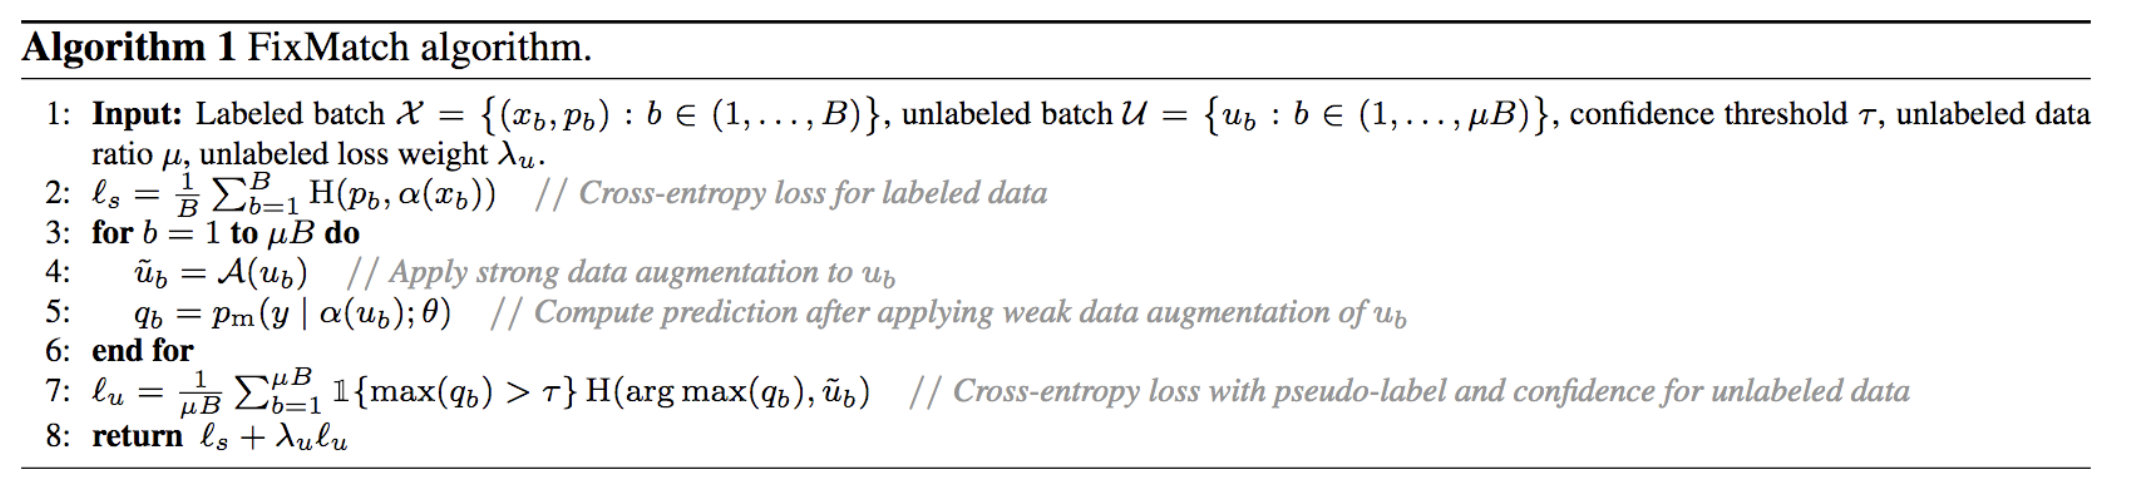

In [15]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TPIA3_3/images/fixmatchAlgo.png",width=1100))

 - ligne 4, on fait passer dans le réseau les données fortement augmentées.
 - ligne 7, la cross-entropy H est calculée entre les targets, pseudo-labels obtenues avec argmax sur q_b 
 - les logits obtenus par une passe forward sur les données augmentées fortement.

In [16]:
def sup_prepare_batch(batch, device, non_blocking):
    x = batch["image"].to(device, non_blocking=non_blocking)
    y = batch["target"].to(device, non_blocking=non_blocking)
    return x, y

In [17]:
confidence_threshold = 0.95
lambda_u = 1.0

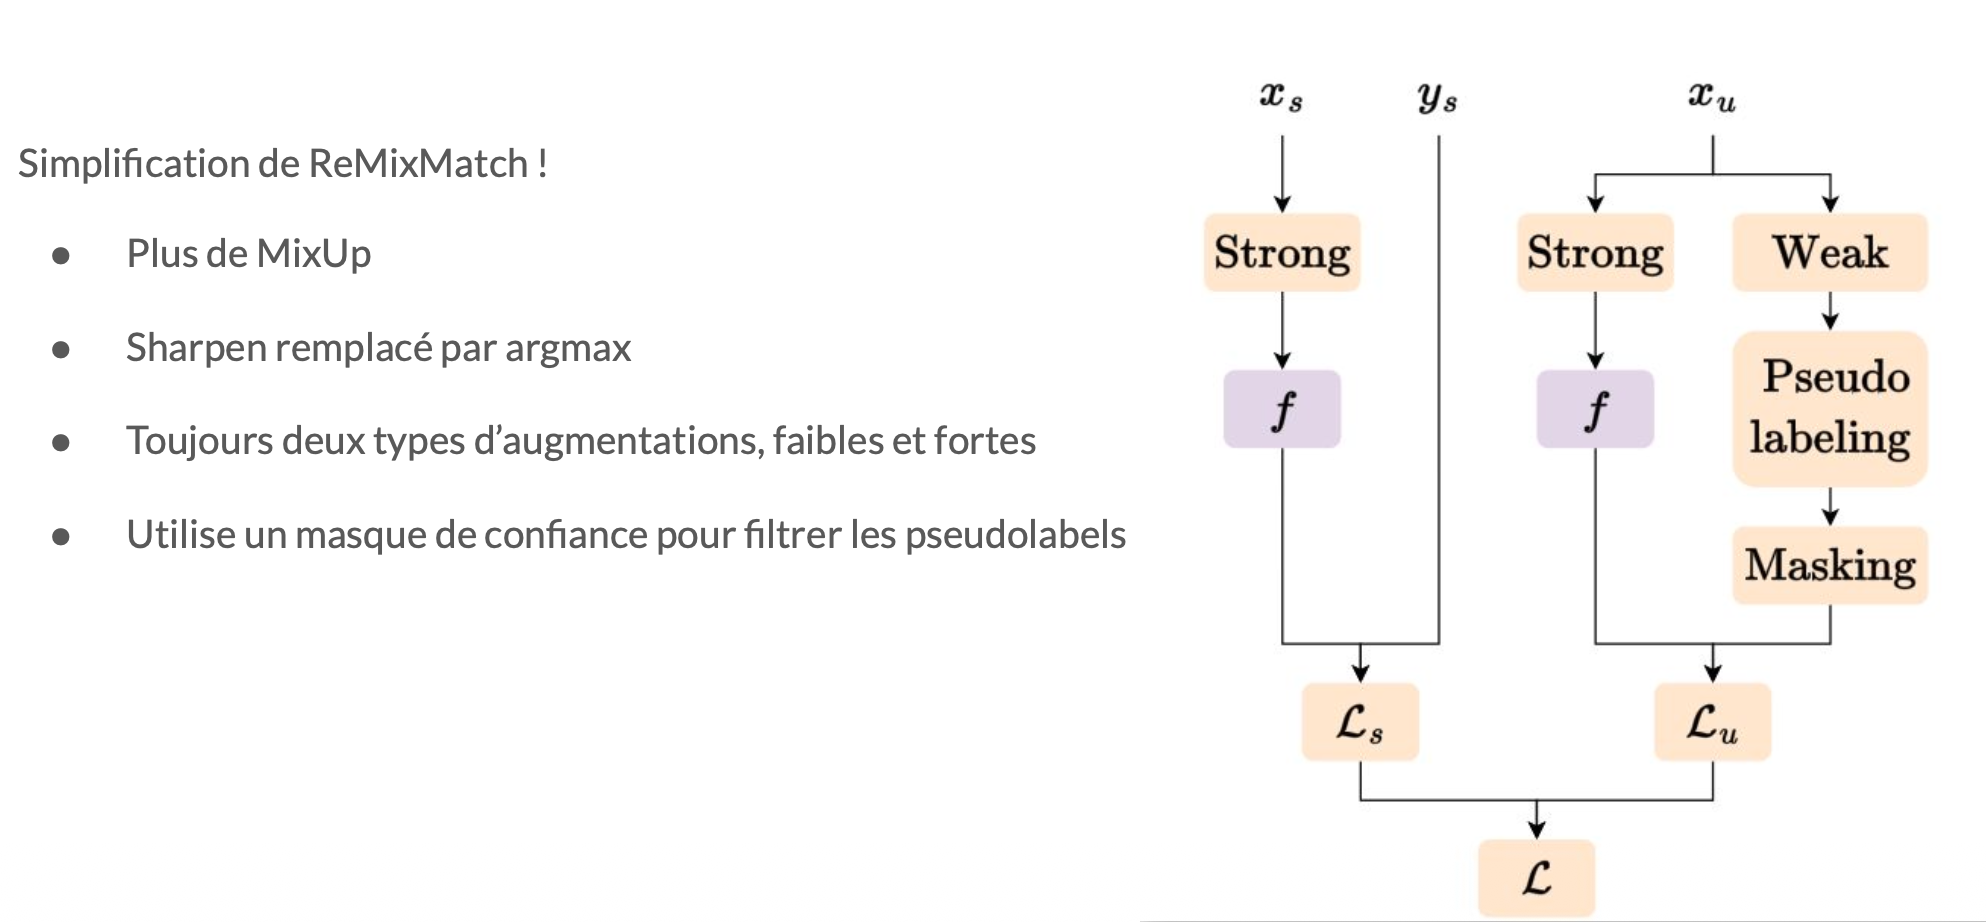

In [18]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TPIA3_3/images/MixMatch.png",width=700))

In [ ]:
# Cette fonction crée un itérateur infini sur ton dataloader, 
# qui renvoie les batchs en boucle sans jamais s’arrêter.
# cycle donne un flux infini de batchs, 
def cycle(dataloader):
    while True:
        for b in dataloader:
            yield b

# Chaque appel à step() consomme un batch supervisé et un batch non supervisé.
def fixMatchstepAlgo(
                model, 
                sup_criterion, 
                unsup_criterion,
                optimizer, 
                lr_scheduler, 
                supervised_train_loader_iter, 
                unsupervised_train_loader_iter, 
                device 
            ):
    # 1. Mise en mode train et reset des gradients
    model.train()
    optimizer.zero_grad()

    # ----- partie supervisée -----
    # 2. Partie supervisée (batch labellisé)
    sup_batch = next(supervised_train_loader_iter) # weak_transforms supervised
    x, y = sup_prepare_batch(sup_batch, device, non_blocking=True) # x= image , y =target
    y_pred = model(x) # prédiction de classe 
    sup_loss = sup_criterion(y_pred, y)   # scalaire = loss prédiction sur la prédiction

    # ----- partie pseudo-labeling (FixMatch) -----
    # 3. Partie non supervisée (FixMatch, pseudo‑labels)
    unsup_batch = next(unsupervised_train_loader_iter) # batch strong_aug_transforms unsupervised
    weak_x = unsup_batch["image"].to(device, non_blocking=True) # tensor image
    # weak_x.shape : torch.Size([896, 3, 32, 32])
    strong_x = unsup_batch["strong_aug"].to(device, non_blocking=True) # tensor augmentation
    # strong_x.shape : torch.Size([896, 3, 32, 32])

    # logits sur weak et strong
    # On obtient les logits sur weak et strong pour le même batch d’images.
    y_weak_logits = model(weak_x)  # retourne prédiction classes les images du batch weakly modified
    # print(f'y_weak_logits.shape : {y_weak_logits.shape}')     # y_weak_logits.shape : torch.Size([896, 10])
    y_strong_logits = model(strong_x)           # retourne la prédiction liée à la déformation
    # print(f'y_strong_logits.shape : {y_strong_logits.shape}') # y_strong_logits.shape : torch.Size([896, 10])

    # 1) pseudo-labels à partir des weak
    y_weak_probs = torch.softmax(y_weak_logits, dim=1)  
    # print(f'y_weak_probs.shape : {y_weak_probs.shape}') # y_weak_probs.shape : torch.Size([896, 10])
    y_pseudo = torch.argmax(y_weak_probs, dim=1)    
    # print(f'y_pseudo.shape : {y_pseudo.shape}') # y_pseudo.shape : torch.Size([896])
    # 2) confiance de la classe prédite
    max_probs = y_weak_probs.gather(1, y_pseudo.unsqueeze(1)).squeeze(1)  # (B,)
    # print(f'max_probs.shape : {max_probs.shape}') # max_probs.shape : torch.Size([896])
    unsup_loss_mask = max_probs >= confidence_threshold                   # (B,) bool
    # print(f'unsup_loss_mask[:10] : {unsup_loss_mask[:10]}') #[False, True,... False, False]
    # 3) loss non supervisée par échantillon
    per_sample_unsup_loss = unsup_criterion(y_strong_logits, y_pseudo)    # (B,)

    # 4) garder seulement les échantillons confiants et moyenner
    #.   True si au moins un échantillon du batch est confiant.
    #    False si aucun échantillon ne dépasse le seuil de confiance
    if unsup_loss_mask.any(): # retourne un scalaire booléen
        unsup_loss = per_sample_unsup_loss[unsup_loss_mask].mean()
    else:
        unsup_loss = torch.tensor(0.0, device=device)
    # ----- loss totale -----
    total_loss = sup_loss + lambda_u * unsup_loss    # scalaire

    total_loss.backward()
    optimizer.step()
    lr_scheduler.step()

    return {
    "total_loss": total_loss.item(),
    "sup_loss": sup_loss.item(),
    "unsup_loss": unsup_loss.item(),
    "non_zero_unsup_loss_density": unsup_loss_mask.float().mean().item(),
    }

### `1.8 Test`
`Accuracy`.  
 - cette fonction calcule la précision « top‑k »,
 - c’est‑à‑dire le % d’images dont la vraie classe est dans les k prédictions les plus probables du modèle.
`output.topk(maxk, dim=1, largest=True, sorted=True)` 
Le tenseur output de taille (batch_size, num_classes) contient les scores (logits) de chaque classe :
 - la fonction topk, pour chaque élément du batch, prends les maxk classes ayant les scores les plus élevés, et retourne les indices.
 - on écrit _, pred = ..., implique que l'on ne conserve que les indices des classes dans pred.
 - si maxk = 5, alors pour chaque élément du batch on obtient les indices des 5 classes les plus probables.

On transpose pour avoir pred de forme (maxk,batch_size) : 
 - chaque colonne = un exemple, 
 - chaque ligne = la 1re, 2e, ..., k‑ème meilleure prédiction. 

__`précision en pourcentage d’exemples pour lesquels la classe prédite la plus probable est exactement le label vrai`__
 - __prec1__ : pourcentage pour lesquel la classe prédite la plus probable est exactement le label vrai.
 - __prec5__ : pourcentage pour lesquels le label vrai est dans les 5 classes les plus probables du modèle`.

In [20]:
def accuracy(output, target, topk=(1,)):
    """Computes the precision@k for the specified values of k"""
    maxk = max(topk)
    batch_size = target.size(0)
    # output: (batch_size, num_classes)
    # la fonction topk les retourne les maxk plus grands scores sur la dimension des classes (dim=1),
    # et les indices de ces scores (c’est‑à‑dire les indices de classes).
    # pred: (batch_size, maxk) sont les indices des maxk classes les plus probables
    _, pred = output.topk(maxk, 1, True, True)
    # on transpose pour obtenir (maxk, batch_size)
    pred = pred.t()
    # target: (batch_size,) -> reshape en (1, batch_size)
    # expand_as(pred): (maxk, batch_size)
    # correct: booléen, True si la target est dans le top-k
    correct = pred.eq(target.reshape(1, -1).expand_as(pred))

    res = []
    for k in topk:
        # on ne garde que les k premières lignes (top-k)
        # puis on aplatit, convertit en float (True=1, False=0) et on somme    
        correct_k = correct[:k].reshape(-1).float().sum(0)
       # pourcentage d’exemples corrects dans le batch 
        res.append(correct_k.mul_(100.0 / batch_size))
    return res

def test(device, sup_criterion, test_loader, model, epoch):
    test_loss = 0.0
    top1 = 0.0
    top5 = 0.0

    with torch.no_grad():
        for batch_idx, dico in enumerate(test_loader):
            model.eval()

            inputs = dico["image"]
            targets = dico["target"]
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = sup_criterion(outputs, targets)

            prec1, prec5 = accuracy(outputs, targets, topk=(1, 5))
            test_loss += loss.item()
            top1 += prec1.item()
            top5 += prec5.item()
            """
            print("Test Iter: {batch:4}/{iter:4}. Loss: {loss:.4f}. top1: {top1:.2f}. top5: {top5:.2f}. ".format(
                     batch=batch_idx + 1,
                     iter=len(test_loader),
                     loss=test_loss,
                     top1=top1,
                     top5=top5,
             ))
             """

    print("test top-1 acc: {:.2f} % pour lesquel la classe prédite la plus probable est exactement le label vrai".format(top1/len(test_loader)))
    print("test top-5 acc: {:.2f} % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle".format(top5/len(test_loader)))
    return test_loss/len(test_loader), top1/len(test_loader)

### `1.9 Apprentissage`

#### __`Phase d'apprentissage`__
:::
__`Lancement de la procédure de test avant l'entrainement du modèle ?`__.  
 - C’est une pratique standard en entraînement de modèles :
 - On mesure la performance du modèle à l’état initial (poids aléatoires, ou pretrained non fine‑tuné).
 - Ensuite, à chaque epoch, on appelle le test(...) pour suivre l'évolution de la performance.
 - Cela permet de tracer un graphe epoch → accuracy où le point epoch=0 est la baseline.
:::
:::
__`REMARQUE:`__    
 - `Les valeurs de loss s'accumulent au cours des mini-batchs,` 
 - `c'est la raison pour laquelle, elles augmentent au cours des epochs!`
:::

In [ ]:
import time

def train_model(model, 
                sup_criterion, 
                unsup_criterion,
                optimizer,
                lr_scheduler,
                supervised_train_loader_iter,
                unsupervised_train_loader_iter, 
                test_loader,
                epoch_length,
                num_epochs,
                device,
                initial_epoch=0):
    print(f'############# Débul du calcul de la performance du modèle WiseNet à l\'état initial #####################')
    test_loss, test_top1_acc = test(device, sup_criterion, test_loader, model, initial_epoch)
    print(f'############# Début de l\'apprentissage modèle WiseNet #####################')
      
    for epoch in range(num_epochs):
        epoch_total_loss, epoch_sup_loss, epoch_unsup_loss  = 0., 0., 0.

        for it in range(epoch_length):
            t0 = time.time()
            dico = fixMatchstepAlgo(
                        model, 
                        sup_criterion, 
                        unsup_criterion,
                        optimizer, 
                        lr_scheduler, 
                        supervised_train_loader_iter, 
                        unsupervised_train_loader_iter, 
                        device 
                        )
            dt = time.time() - t0
        if it % 10 == 0:
            print(f"[DEBUG] it={it}/{epoch_length}, dt={dt:.3f}s")
            
            epoch_total_loss += dico["total_loss"]
            epoch_sup_loss += dico["sup_loss"]
            epoch_unsup_loss += dico["unsup_loss"]
        
            if it % 1000 == 0:
                print("Batch: {it}/{epoch_length:4} --- Loss: {epoch_total_loss:.5f} sup_loss: {epoch_sup_loss:.5f} unsup_loss: {epoch_unsup_loss:.5f}".format(
                    it=it,
                    epoch_length=epoch_length,
                    epoch_total_loss=epoch_total_loss,
                    epoch_sup_loss=epoch_sup_loss,
                    epoch_unsup_loss=epoch_unsup_loss
                    ))
          
        epoch_total_loss /= epoch_length
        epoch_sup_loss /= epoch_length
        epoch_unsup_loss /= epoch_length
        print("Train Epoch: {epoch}/{num_epochs:4} --- Loss: {epoch_total_loss:.5f} sup_loss: {epoch_sup_loss:.5f} unsup_loss: {epoch_unsup_loss:.5f}".format(
                    epoch=epoch+1,
                    num_epochs=num_epochs,
                    epoch_total_loss=epoch_total_loss,
                    epoch_sup_loss=epoch_sup_loss,
                    epoch_unsup_loss=epoch_unsup_loss
                ))
        print(f"############# Début du test modèle WiseNet ################################")
        test_loss, test_top1_acc = test(device, sup_criterion, test_loader, model, epoch)

### `1.9 Instantiation du modèle WideResnet`

In [ ]:
sup_criterion = nn.CrossEntropyLoss()
unsup_criterion = nn.CrossEntropyLoss(reduction='none')

num_epochs = 16  # orginally 1024
epoch_length = 65536 // batch_size
K = num_epochs * epoch_length

supervised_train_loader_iter = cycle(supervised_train_loader) # weak_transforms supervised
unsupervised_train_loader_iter = cycle(unsupervised_train_loader) # Weak + strong_aug_transforms unsupervised

In [ ]:
modelWideResNet = WideResNet(num_classes=10).to(device)

if torch.cuda.device_count() > 1:
    modelWideResNet = nn.parallel.DataParallel(modelWideResNet)

optimizer = optim.SGD(modelWideResNet.parameters(), lr=0.03, momentum=0.9, nesterov=True, weight_decay=weight_decay)
print(f'nombre de paramètre : {sum([p.numel() for p in modelWideResNet.parameters()])}')
lr_scheduler = lrs.CosineAnnealingLR(optimizer, K)    

train_model(modelWideResNet, 
            sup_criterion, 
            unsup_criterion,
            optimizer,
            lr_scheduler,
            supervised_train_loader_iter,
            unsupervised_train_loader_iter, 
            test_loader,
            epoch_length,
            num_epochs,
            device,
            )

nombre de paramètre : 1469642


### `1.11 Nettoyage de la mémoire`

In [ ]:
# 1. Modèle + optimizer
del modelWideResNet
del optimizer

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.mps.empty_cache()   # sur NVidia   


## __` 2 ResNet18`__
:::
`Le ResNet18 pré‑entraîné ImageNet est conçu pour 1000 classes`.
 - Sa dernière couche est typiquement Linear(in_features=512, out_features=1000, bias=True)
 - CIFAR10 n’a que 10 classes, nous devons donc remplacer cette couche
:::

:::
__`Problème de consommation de ressources et de temps d'apprentissage`__.  
 - ResNet18 pré‑entraîné ImageNet → première conv + maxpool pensés pour 224×224, 
 - beaucoup de FLOPs inutiles sur des images CIFAR‑10 upscalées en 256→224.
 - Resize(256) puis RandomCrop(224) partout (sup, unsup, test) → multiplies par ~50 le coût/image % à du 32×32.

`strong_transforms très agressif` 
 - RandomAffine + plusieurs flips + ColorJitter + RandomErasing 
 - sur des gros tensors → coût CPU important, surtout avec num_workers=0 (requis pour mps).

`unsupervised_train_loaderResNet`.  
 - avec batch_size * mu_ratio → le batch non supervisé peut être énorme.
 - avec 76 s par itération n’est pas faisable sur une machine avec des ressources modeste.
:::

__`Alternative passer à un ResNet18 adapté CIFAR‑10 (32×32)`__
:::
Pour adapter un ResNet18 “ImageNet” à CIFAR‑10/100 (images 32×32), les modifications se font essentiellement au début (stem) et à la fin du réseau, pas dans les blocs résiduels eux‑mêmes.

`1. Entrée / stem (conv1 + maxpool)`
Pour CIFAR‑10/100 (32×32), on remplace le ResNet18 ImageNet classique :
 - conv1 : (conv 7×7, stride 2, padding 3) __par__ (conv 3×3, stride 1, padding 1, mêmes 64 canaux de sortie)
 - maxpool : (maxpool 3×3, stride 2) supprimé ou remplacé __par__ (nn.Identity())
::: 

In [ ]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights=None)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1,padding=1, bias=False)
model.maxpool = nn.Identity()

### `2.1 Instantiation du modèle Resnet`

In [ ]:
from torchvision import models, transforms
import torch.nn as nn

# modèle
#modelresnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
modelresnet18 = models.resnet18(weights=None)  # pas de pré-entraînement
modelresnet18.fc = nn.Linear(modelresnet18.fc.in_features, num_classes)
modelresnet18 = modelresnet18.to(device)

##
print(f'nombre de paramètre : {sum([p.numel() for p in modelresnet18.parameters()])}')
##

if torch.cuda.device_count() > 1:
    modelWideResNet = nn.parallel.DataParallel(modelresnet18)

optimizer = optim.SGD(modelresnet18.parameters(), lr=0.03, momentum=0.9, nesterov=True, weight_decay=weight_decay)
print(f'nombre de paramètre : {sum([p.numel() for p in modelresnet18.parameters()])}')
lr_scheduler = lrs.CosineAnnealingLR(optimizer, K)    

train_model(modelWideResNet, 
            sup_criterion, 
            unsup_criterion,
            optimizer,
            lr_scheduler,
            supervised_train_loader_iter,
            unsupervised_train_loader_iter, 
            test_loader,
            epoch_length,
            num_epochs,
            device,
            )

nombre de paramètre : 11181642
num_epochs : 16 , epoch_length : 1024, K : 16384


#### `2.2 Test TrainLoader pour ResNet18`
:::
 - ResNet18 pré‑entraîné sur ImageNet, images de 224×224 RGB, normalisation spécifique (moyennes/écarts‑types ImageNet). 
 - CIFAR10 fournit des images 32×32, non normalisées comme ImageNet, 
 - Si l'on n'adapte pas les caractéristiques de transforms, les images en 32×32 passent quand même, 
 - par contre les features apprises sur 224×224 ne sont plus exploitées de manière cohérente (réception field, downsampling, etc.).
 - Avec CIFAR10 la distribution des pixels vue par le réseau étant très différente de ce qu’il a vu pendant le pré‑entraînement
 - Ne pas utiliser la bonne normalisation rompt l’intérêt du transfert.
:::

In [ ]:
# transform pour CIFAR10 (weak augment pour le supervisé par ex.)
#imagenet_mean = [0.485, 0.456, 0.406]
#imagenet_std  = [0.229, 0.224, 0.225]
cifar_mean = [0.4914, 0.4822, 0.4465]
cifar_std  = [0.2470, 0.2435, 0.2616]

transform_test = T.Compose([
    #T.Resize(256),
    #T.CenterCrop(224),
    T.ToTensor(),
    #T.Normalize(mean=imagenet_mean,std=imagenet_std),
    T.Normalize(mean=cifar_mean,std=cifar_std),
])
test_loaderResNet = DataLoader(
    TransformedDataset(
        full_test_dataset,
        transforms=lambda dp: {"image": transform_test(dp[0]), "target": dp[1]}
    ),
    batch_size=batch_size, num_workers=0, pin_memory=False, drop_last=False, shuffle=False
)

#### `2.3 Supervised TrainLoader pour ResNet18`

In [ ]:
supervised_train_indices = []
counter = [0] * num_classes

for i, dp in enumerate(full_train_dataset): # (<PIL.Image.Image image mode=RGB size=32x32 at 0x132A5F910>, 6)
    if len(supervised_train_indices) >= num_classes * num_train_samples_per_class:
        break
    if counter[dp[1]] < num_train_samples_per_class: # limite le nombre de classes
        counter[dp[1]] += 1 # incrémente à l'indice de la classe le nombre d'occurence [0,  2, 0, 0, 1, 0, 1, 0, 0, 2]
        supervised_train_indices.append(i)

for cls_id, n in enumerate(counter):
    print(f"{n} échantillons de la classe {id2label[cls_id]}")
print(f"Total : {sum(counter)}")

print(f'sum(counter) : {sum(counter)}')
supervised_train_dataset = Subset(full_train_dataset, supervised_train_indices)
print(f'le nombre de classe pour le trainset est de {len(supervised_train_dataset)}')

25 échantillons de la classe airplane
25 échantillons de la classe automobile
25 échantillons de la classe bird
25 échantillons de la classe cat
25 échantillons de la classe deer
25 échantillons de la classe dog
25 échantillons de la classe frog
25 échantillons de la classe horse
25 échantillons de la classe ship
25 échantillons de la classe truck
Total : 250
sum(counter) : 250
le nombre de classe pour le trainset est de 250


In [ ]:
# Weak augmentation (FixMatch)
weak_transforms = T.Compose([
    #T.Resize(256),
    #T.RandomCrop(224, padding=4),
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    #T.Normalize(mean=imagenet_mean, std=imagenet_std),
    T.Normalize(mean=cifar_mean, std=cifar_std),
])

supervised_train_loaderResNet = DataLoader(
    TransformedDataset(
        supervised_train_dataset,
        transforms=lambda dp: {"image": weak_transforms(dp[0]), "target": dp[1]}
    ),
    batch_size=batch_size, num_workers=0, pin_memory=False, drop_last=False, shuffle=True
)

#### `2.4 Unsupervised TrainLoader pour ResNet`

In [ ]:

strong_transforms = T.Compose([
    #T.RandomAffine(45, translate=(0.2, 0.2), scale=(0.7, 1.2), shear=10),
    #T.Resize(256),
    #T.RandomCrop(224, padding=4),
    T.RandomCrop(4, padding=4),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(0.15, 0.15, 0.15, 0.15),
    T.ToTensor(),
    #T.Normalize(mean=imagenet_mean, std=imagenet_std),
    T.Normalize(mean=cifar_mean, std=cifar_std),
    T.RandomErasing(scale=(0.02, 0.05))
])

unsupervised_train_datasetResNet = TransformedDataset(
    full_train_dataset,
    transforms=lambda dp: {"image": weak_transforms(dp[0]), "strong_aug": strong_transforms(dp[0])}
)

unsupervised_train_loaderResNet = DataLoader(
    unsupervised_train_datasetResNet,
    batch_size=batch_size * mu_ratio, num_workers=0, pin_memory=False, drop_last=False, shuffle=True
)

### `2.5 Extrait de la transformation`

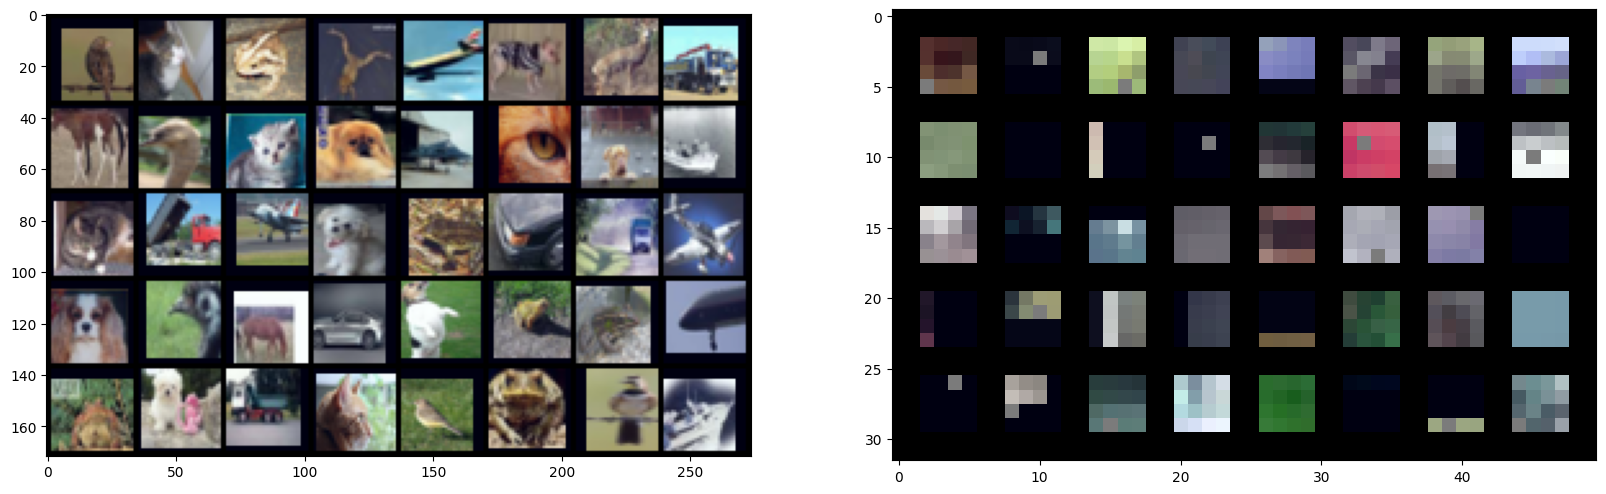

In [ ]:
unsupervised_train_loader_iter = iter(unsupervised_train_loaderResNet)
unsup_batch = next(unsupervised_train_loader_iter)

unsup_weak_aug_batch = make_grid(unsup_batch["image"][:40, ...], normalize=True)
unsup_strong_aug_batch = make_grid(unsup_batch["strong_aug"][:40, ...], normalize=True)
plt.figure(figsize=(20, 7))
plt.subplot(121)
plt.imshow(unsup_weak_aug_batch.numpy().transpose((1, 2, 0)))
plt.subplot(122)
plt.imshow(unsup_strong_aug_batch.numpy().transpose((1, 2, 0)))
plt.show()

### `2.6 Apprentissage du modèle ResNet18`.   
- ResNet-18 pré‑entraîné « standard » pour classifier 1000 classes, celles du dataset ImageNet (ILSVRC)

In [ ]:
supervised_train_loader_iter = cycle(supervised_train_loaderWiseNet) # weak_transforms supervised
unsupervised_train_loader_iter = cycle(unsupervised_train_loaderWiseNet) # Weak + strong_aug_transforms unsupervised
train_model(modelresnet18,supervised_train_loader_iter,unsupervised_train_loader_iter)

In [ ]:
import time

initial_epoch = 0
model = modelresnet18

supervised_train_loader_iter = cycle(supervised_train_loaderResNet) # weak_transforms supervised
unsupervised_train_loader_iter = cycle(unsupervised_train_loaderResNet) # Weak + strong_aug_transforms unsupervised

print(f'############# Débul du calcul de la performance du modèle ResNet18 à l\'état initial #####################')
test_loss, test_top1_acc = test(device, sup_criterion, test_loaderResNet, model, initial_epoch)
print(f'############# Début de l\'apprentissage modèle ResNet18 #####################')
for epoch in range(num_epochs):
    epoch_total_loss, epoch_sup_loss, epoch_unsup_loss  = 0., 0., 0.

    for it in range(epoch_length):
        t0 = time.time()
        dico = fixMatchstepAlgo(model,optimizer, lr_scheduler, sup_criterion,unsup_criterion)
        dt = time.time() - t0
        if it % 10 == 0:
            print(f"[DEBUG] it={it}/{epoch_length}, dt={dt:.3f}s")

        epoch_total_loss += dico["total_loss"]
        epoch_sup_loss += dico["sup_loss"]
        epoch_unsup_loss += dico["unsup_loss"]
        
        if it % 1000 == 0:
          print("Batch: {it}/{epoch_length:4} --- Loss: {epoch_total_loss:.5f} sup_loss: {epoch_sup_loss:.5f} unsup_loss: {epoch_unsup_loss:.5f}".format(
              it=it,
              epoch_length=epoch_length,
              epoch_total_loss=epoch_total_loss,
              epoch_sup_loss=epoch_sup_loss,
              epoch_unsup_loss=epoch_unsup_loss
          ))
          
    epoch_total_loss /= epoch_length
    epoch_sup_loss /= epoch_length
    epoch_unsup_loss /= epoch_length
    print("Train Epoch: {epoch}/{num_epochs:4} --- Loss: {epoch_total_loss:.5f} sup_loss: {epoch_sup_loss:.5f} unsup_loss: {epoch_unsup_loss:.5f}".format(
        epoch=epoch+1,
        num_epochs=num_epochs,
        epoch_total_loss=epoch_total_loss,
        epoch_sup_loss=epoch_sup_loss,
        epoch_unsup_loss=epoch_unsup_loss
    ))
    print(f'############# Début du test modèle ResNet ################################')
    test_loss, test_top1_acc = test(device, sup_criterion, test_loaderResNet, model, epoch)


############# Débul du calcul de la performance du modèle ResNet18 à l'état initial #####################


test top-1 acc: 10.07 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 43.08 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
############# Début de l'apprentissage modèle ResNet18 #####################


[DEBUG] it=0/1024, dt=76.364s
Batch: 0/1024 --- Loss: 2.53386 sup_loss: 2.53386 unsup_loss: 0.00000


KeyboardInterrupt: 

### `2.7 Nettoyage de la mémoire`

In [ ]:
# 1. Modèle + optimizer
del modelresnet18
del optimizer

# 2. Datasets + DataLoader liés à cette expérience
del supervised_train_dataset
del unsupervised_train_datasetWiseNet
del test_loaderWiseNet
del supervised_train_loaderWiseNet
del unsupervised_train_loaderWiseNet

# 3. Tensors / variables temporaires volumineuses, si tu en as
# del big_tensor, all_batches, etc.

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.mps.empty_cache()   # sur NVidia   